# Machine Learning Exam - Football Matches

# Stage 1: Problem Foundation
## Hypothesis

### Der er en relation mellem regnvejr og en kamps udspil
* Der scores flere mål i regnvejrskampe end tørvejrskampe
* Der bliver uddelt flere kort i regnvejrskampe vs tørvejr
* Bliver der generelt lavet flere “fouls” i en regnvejrskamp?
* Der bliver dømt flere straffespark i regnvejr end tørvejskampe

### Der er en relation mellem hjemmebanefordel og vundne kampe
* Man vinder oftere med hjemmebanefordel
* Hjemmebanehold får færre “fouls” stemt imod sig end udebanehold
* Udebanehold har flere kort pr. foul end hjemmebanehold

### Der er en relation mellem spilstrategi og vundne kampe
* Højere skud procent fører til flere mål

### Straffespark / Hjørnespark / Frispark (Individuel data pr. kamp)
* Mængden af kort et hold modtager har en korrelation til at man taber kampen
* Mængden af kort et hold modtager har en korrelation til at man vinder kampen
* Mængden af hjørnespark har en korrelation til at vinde kampe
* Man vinder flere kampe, jo flere frispark et hold får dømt til deres fordel

# Stage 2: Data Preparation And Exploration
## Data Collection
### Import data
Her importerer vi vores raw data vi har fået. Dataen er fodbold-kamp data fra perioden 2025-02-04 -3026-03-13

In [39]:
import pandas as pd
rawdf = pd.read_csv("data/matchdataraw.csv")
cleaneddf = rawdf.copy()
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,XGPERSHOT,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK
0,335,1699867,7458,11,9,4,0,1,2,65,0,0.077,20.7,0.8455,11,13,8,1,2,7,1,0,8,4,0,0,4,23,8,15,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
1,335,1699867,7499,12,8,4,0,0,0,28,2,0.083,22.6,0.9959,5,11,9,7,2,8,4,0,3,4,3,2,4,17,10,7,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
2,335,1699868,7456,5,14,2,0,1,2,19,0,0.069,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00.000,2015-07-18 13:00:00.000,Played,335,9493,4165479,1
3,335,1699868,7455,12,16,4,0,1,1,32,2,0.077,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00.000,2015-07-18 13:00:00.000,Played,335,9493,4165479,1
4,335,1699869,7460,14,10,4,0,1,0,38,3,0.097,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00.000,2015-07-19 10:30:00.000,Played,335,9493,4165479,1


## Cleaning
### Håndtering af NaN

In [40]:
cleaneddf.isnull().sum
cleaneddf.isna().sum()

COMPETITION_WYID           0
MATCH_WYID                 0
TEAM_WYID                  0
SHOTS                      0
FOULS                      0
CORNERS                    0
REDCARDS                   0
YELLOWCARDS                0
OFFSIDES                   0
DRIBBLES                   0
GOALS                      0
XGPERSHOT                  0
AVGDISTANCE                0
XG                         0
PROGRESSIVERUNS            0
TOUCHESINBOX               0
FOULSSUFFERED              0
SHOTSONTARGET              0
SHOTSBLOCKED               0
SHOTSOUTSIDEBOX            0
SHOTSOUTSIDEBOXONTARGET    0
SHOTSONPOST                0
SHOTSWIDE                  0
SHOTSFROMBOX               0
SHOTSFROMBOXONTARGET       0
FREEKICKS                  0
SHOTSFROMDANGERZONE        0
TOTALTHROWINS              0
LEFTTHROWINS               0
RIGHTTHROWINS              0
MATCH_WYID.1               0
MATCHLABEL                 0
DATE                       0
DATEUTC                    0
MATCHSTATUS   

### Håndtering af duplikeret rækker

In [41]:
cleaneddf.duplicated().sum()

np.int64(0)

### Håndtering af inkonsistente værdier (Danmark,DK)
  Vi fjerner "Expected goals per shot (XGPERSHOT)" pga. den er inkonsistent og der mangler data / forklaring på hvordan den laves korrekt

In [42]:
cleaneddf.drop(columns=["XGPERSHOT"], inplace=True)
print("XGPERSHOT i kolonner?", "XGPERSHOT" in cleaneddf.columns)

XGPERSHOT i kolonner? False


### Håndtering af outliers

Vi finder vores ekstreme outliers

In [43]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


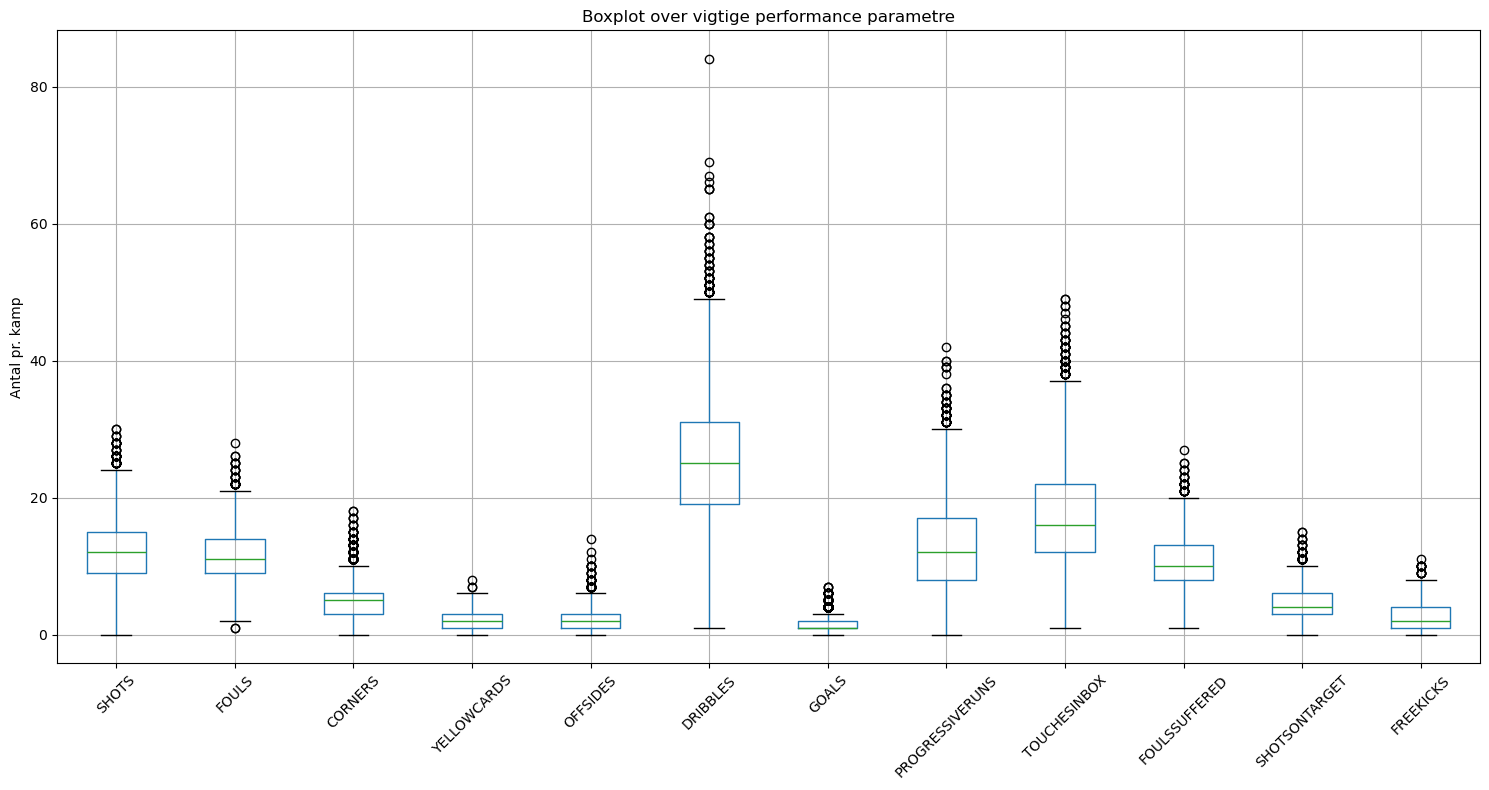

In [44]:
import matplotlib.pyplot as plt

performance_cols = [
    'SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'OFFSIDES', 
    'DRIBBLES', 'GOALS', 'PROGRESSIVERUNS', 'TOUCHESINBOX', 
    'FOULSSUFFERED', 'SHOTSONTARGET', 'FREEKICKS'
]

plt.figure(figsize=(15, 8))
cleaneddf[performance_cols].boxplot()

plt.xticks(rotation=45)
plt.title('Boxplot over vigtige performance parametre')
plt.ylabel('Antal pr. kamp')
plt.tight_layout()
plt.show()

In [45]:
# Vi finder hvilken outlier der er ekstrem i dribbles kategorien
outliers = cleaneddf[cleaneddf['DRIBBLES'] > 62]
display(outliers.head())

# Vi definerer en liste med alle de kamp-ID'er, vi vil ha fjernet
matches_to_remove = [1699867, 1699952, 2497370, 2720158, 2818322, 1699964]

# Vi sikrer at kolonnen er integer 
cleaneddf['MATCH_WYID'] = cleaneddf['MATCH_WYID'].astype(int)

# Vi fjerner listen
cleaneddf = cleaneddf[~cleaneddf['MATCH_WYID'].isin(matches_to_remove)]

# Vi dobbelt tjekker om de er blevet fjernet
outliers_check = cleaneddf[cleaneddf['DRIBBLES'] > 62]
display(outliers_check.head())

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK
0,335,1699867,7458,11,9,4,0,1,2,65,0,20.7,0.8455,11,13,8,1,2,7,1,0,8,4,0,0,4,23,8,15,1699867,"Nordsjælland - SønderjyskE, 0 - 2",2015-07-17 17:00:00.000,2015-07-17 15:00:00.000,Played,335,9493,4165479,1
162,335,1699952,7457,10,9,6,0,1,1,67,1,23.5,0.3297,6,8,12,2,4,9,2,0,4,1,0,3,1,23,9,14,1699952,"Randers - AGF, 4 - 1",2015-11-06 19:30:00.000,2015-11-06 18:30:00.000,Played,335,9493,4165479,15
182,335,1699964,7456,11,17,6,0,1,3,65,1,21.5,0.9750,8,12,5,4,4,7,2,0,3,4,2,3,4,32,21,11,1699964,"Viborg - AGF, 1 - 0",2015-11-27 17:00:00.000,2015-11-27 16:00:00.000,Played,335,9493,4165479,17
183,335,1699964,7457,10,7,3,0,1,2,84,0,24.3,0.3538,17,9,8,2,4,7,2,0,4,3,0,6,1,24,10,14,1699964,"Viborg - AGF, 1 - 0",2015-11-27 17:00:00.000,2015-11-27 16:00:00.000,Played,335,9493,4165479,17
1107,335,2497370,7461,16,7,8,0,0,2,65,1,15.5,2.3040,11,22,15,4,7,4,0,0,5,12,4,5,7,36,10,26,2497370,"Silkeborg - Brøndby, 1 - 3",2017-11-26 18:00:00.000,2017-11-26 17:00:00.000,Played,335,181370,4405217,17


,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK


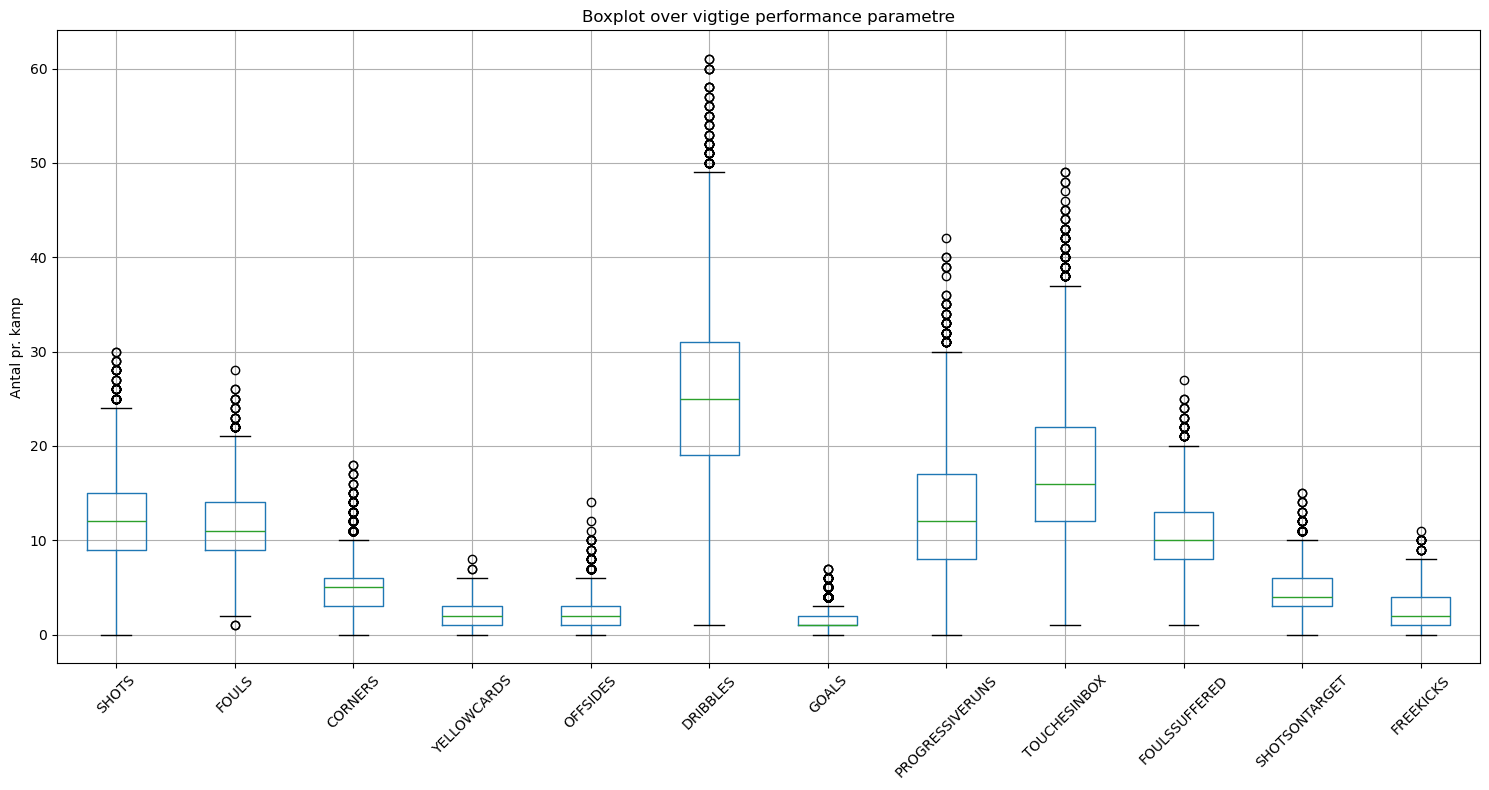

In [46]:
import matplotlib.pyplot as plt

performance_cols = [
    'SHOTS', 'FOULS', 'CORNERS', 'YELLOWCARDS', 'OFFSIDES', 
    'DRIBBLES', 'GOALS', 'PROGRESSIVERUNS', 'TOUCHESINBOX', 
    'FOULSSUFFERED', 'SHOTSONTARGET', 'FREEKICKS'
]

plt.figure(figsize=(15, 8))
cleaneddf[performance_cols].boxplot()

plt.xticks(rotation=45)
plt.title('Boxplot over vigtige performance parametre')
plt.ylabel('Antal pr. kamp')
plt.tight_layout()
plt.show()

## Structering
### Vejr data

## Transformation
### Kategoriske værdier til numeriske

In [47]:
cleaneddf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4528 entries, 2 to 4539
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   COMPETITION_WYID         4528 non-null   int64  
 1   MATCH_WYID               4528 non-null   int64  
 2   TEAM_WYID                4528 non-null   int64  
 3   SHOTS                    4528 non-null   int64  
 4   FOULS                    4528 non-null   int64  
 5   CORNERS                  4528 non-null   int64  
 6   REDCARDS                 4528 non-null   int64  
 7   YELLOWCARDS              4528 non-null   int64  
 8   OFFSIDES                 4528 non-null   int64  
 9   DRIBBLES                 4528 non-null   int64  
 10  GOALS                    4528 non-null   int64  
 11  AVGDISTANCE              4528 non-null   float64
 12  XG                       4528 non-null   float64
 13  PROGRESSIVERUNS          4528 non-null   int64  
 14  TOUCHESINBOX             4528

#### Vi vil gerne lave DATE og DATEUTC om til et datetime objekt

In [48]:
# Konverter DATE og DATEUTC til datetime-objekter
cleaneddf['DATE'] = pd.to_datetime(cleaneddf['DATE'])
cleaneddf['DATEUTC'] = pd.to_datetime(cleaneddf['DATEUTC'])

cleaneddf['weekday'] = cleaneddf['DATE'].dt.day_name() 

print(cleaneddf[['DATE', 'weekday']].head())
cleaneddf.info()

                 DATE   weekday
2 2015-07-18 15:00:00  Saturday
3 2015-07-18 15:00:00  Saturday
4 2015-07-19 12:30:00    Sunday
5 2015-07-19 12:30:00    Sunday
6 2015-07-19 17:00:00    Sunday
<class 'pandas.core.frame.DataFrame'>
Index: 4528 entries, 2 to 4539
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   COMPETITION_WYID         4528 non-null   int64         
 1   MATCH_WYID               4528 non-null   int64         
 2   TEAM_WYID                4528 non-null   int64         
 3   SHOTS                    4528 non-null   int64         
 4   FOULS                    4528 non-null   int64         
 5   CORNERS                  4528 non-null   int64         
 6   REDCARDS                 4528 non-null   int64         
 7   YELLOWCARDS              4528 non-null   int64         
 8   OFFSIDES                 4528 non-null   int64         
 9   DRIBBLES                 4528 

## Categorization

### Kategori med holdnavn og Kategori med nedbør ud fra vejrdata (nedbør mm)


In [49]:
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,MATCHLABEL,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK,weekday
2,335,1699868,7456,5,14,2,0,1,2,19,0,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday
3,335,1699868,7455,12,16,4,0,1,1,32,2,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,"Midtjylland - Viborg, 2 - 0",2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday
4,335,1699869,7460,14,10,4,0,1,0,38,3,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday
5,335,1699869,7510,14,10,2,0,2,2,29,0,22.3,1.2890,3,12,9,9,2,8,6,1,2,6,3,1,3,27,14,13,1699869,"OB - Hobro, 3 - 0",2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday
6,335,1699871,7453,11,20,8,0,1,4,15,1,19.6,0.9837,2,19,10,2,5,4,2,0,4,7,0,4,4,24,13,11,1699871,"AGF - Brøndby, 2 - 1",2015-07-19 17:00:00,2015-07-19 15:00:00,Played,335,9493,4165479,1,Sunday


In [50]:
import pandas as pd
import numpy as np

team_mapping = {
    7458: 'Nordsjælland', 7499: 'SønderjyskE', 7456: 'Viborg', 
    7455: 'Midtjylland', 7460: 'OB', 7510: 'Hobro', 
    7452: 'København', 7462: 'Randers', 7453: 'Brøndby', 
    7457: 'AGF', 7454: 'AaB', 7451: 'Esbjerg', 
    7484: 'Lyngby', 7461: 'Silkeborg', 7465: 'Horsens', 
    7566: 'FC Helsingør', 7488: 'Vendsyssel', 7473: 'Vejle', 
    7490: 'Hvidovre', 7469: 'Fredericia'
}

cleaneddf['TEAM_WYID'] = pd.to_numeric(cleaneddf['TEAM_WYID'], errors='coerce').fillna(0).astype(int)

cleaneddf['Hold'] = cleaneddf['TEAM_WYID'].map(team_mapping)

cleaneddf['Total Cards'] = pd.to_numeric(cleaneddf['REDCARDS'], errors='coerce').fillna(0) + \
                           pd.to_numeric(cleaneddf['YELLOWCARDS'], errors='coerce').fillna(0)

cleaneddf['Total Rain'] = np.nan
cleaneddf['Kategori med nedbør'] = 'Vejrdata mangler'

if 'MATCHLABEL' in cleaneddf.columns:
    matchlabel_data = cleaneddf.pop('MATCHLABEL')
    cleaneddf['MATCHLABEL'] = matchlabel_data

pd.set_option('display.max_columns', None)
cleaneddf.head()

,COMPETITION_WYID,MATCH_WYID,TEAM_WYID,SHOTS,FOULS,CORNERS,REDCARDS,YELLOWCARDS,OFFSIDES,DRIBBLES,GOALS,AVGDISTANCE,XG,PROGRESSIVERUNS,TOUCHESINBOX,FOULSSUFFERED,SHOTSONTARGET,SHOTSBLOCKED,SHOTSOUTSIDEBOX,SHOTSOUTSIDEBOXONTARGET,SHOTSONPOST,SHOTSWIDE,SHOTSFROMBOX,SHOTSFROMBOXONTARGET,FREEKICKS,SHOTSFROMDANGERZONE,TOTALTHROWINS,LEFTTHROWINS,RIGHTTHROWINS,MATCH_WYID.1,DATE,DATEUTC,MATCHSTATUS,COMPETITION_WYID.1,SEASON_WYID,ROUND_WYID,GAMEWEEK,weekday,Hold,Total Cards,Total Rain,Kategori med nedbør,MATCHLABEL
2,335,1699868,7456,5,14,2,0,1,2,19,0,14.1,0.3439,7,7,16,1,0,0,0,0,4,5,1,10,3,31,13,18,1699868,2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday,Viborg,1,NaN,Vejrdata mangler,"Midtjylland - Viborg, 2 - 0"
3,335,1699868,7455,12,16,4,0,1,1,32,2,22.2,0.9293,9,13,14,3,1,7,2,0,8,5,1,7,4,21,9,12,1699868,2015-07-18 15:00:00,2015-07-18 13:00:00,Played,335,9493,4165479,1,Saturday,Midtjylland,1,NaN,Vejrdata mangler,"Midtjylland - Viborg, 2 - 0"
4,335,1699869,7460,14,10,4,0,1,0,38,3,20.9,1.3590,11,16,8,8,3,6,2,0,3,8,6,0,4,18,10,8,1699869,2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday,OB,1,NaN,Vejrdata mangler,"OB - Hobro, 3 - 0"
5,335,1699869,7510,14,10,2,0,2,2,29,0,22.3,1.2890,3,12,9,9,2,8,6,1,2,6,3,1,3,27,14,13,1699869,2015-07-19 12:30:00,2015-07-19 10:30:00,Played,335,9493,4165479,1,Sunday,Hobro,2,NaN,Vejrdata mangler,"OB - Hobro, 3 - 0"
6,335,1699871,7453,11,20,8,0,1,4,15,1,19.6,0.9837,2,19,10,2,5,4,2,0,4,7,0,4,4,24,13,11,1699871,2015-07-19 17:00:00,2015-07-19 15:00:00,Played,335,9493,4165479,1,Sunday,Brøndby,1,NaN,Vejrdata mangler,"AGF - Brøndby, 2 - 1"


## Total info
- Total Cards
- Total Shots
- Total Fouls
- Total Corners
- Total Red cards
- Total Yellow cards
- Total Off-side
- Total Dribbles
- Total Goals
- Total Progressive runs
- Total Free kicks
- Total Throw ins
- Total Rain (hvis vejrdata bliver implemeneteret)

Her samler vi kampene til en kamp. Så to rows bliver til en row der beskriver hele kampen

In [51]:
import pandas as pd
import numpy as np

cols_to_sum = {
    'SHOTS': 'Total Shots',
    'FOULS': 'Total Fouls',
    'CORNERS': 'Total Corners',
    'REDCARDS': 'Total Red cards',
    'YELLOWCARDS': 'Total Yellow cards',
    'OFFSIDES': 'Total Off-side',
    'DRIBBLES': 'Total Dribbles',
    'GOALS': 'Total Goals',
    'PROGRESSIVERUNS': 'Total Progressive runs',
    'FREEKICKS': 'Total Free kicks',
    'TOTALTHROWINS': 'Total Throw ins'
}


match_df = cleaneddf.groupby(['MATCH_WYID', 'MATCHLABEL']).agg({
    **{col: 'sum' for col in cols_to_sum.keys()}
}).reset_index()

match_df.rename(columns=cols_to_sum, inplace=True)

match_df['Total Cards'] = match_df['Total Red cards'] + match_df['Total Yellow cards']

# 5. 
match_df['Total Rain'] = np.nan
match_df['Kategori med nedbør'] = 'Vejrdata mangler'

pd.set_option('display.max_columns', None)
match_df.head()

,MATCH_WYID,MATCHLABEL,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards,Total Rain,Kategori med nedbør
0,1699868,"Midtjylland - Viborg, 2 - 0",17,30,6,0,2,3,51,2,16,17,52,2,NaN,Vejrdata mangler
1,1699869,"OB - Hobro, 3 - 0",28,20,6,0,3,2,67,3,14,1,45,3,NaN,Vejrdata mangler
2,1699870,"København - Randers, 3 - 0",20,29,6,0,3,2,73,3,12,3,51,3,NaN,Vejrdata mangler
3,1699871,"AGF - Brøndby, 2 - 1",21,30,11,0,3,6,30,3,4,6,38,3,NaN,Vejrdata mangler
4,1699872,"AaB - Esbjerg, 1 - 1",36,25,15,0,4,2,52,2,13,1,44,4,NaN,Vejrdata mangler


### Rettelse af enkelte grammatik-fejl

In [52]:
cleaneddf = cleaneddf.replace("SønderjyskE", "Sønderjyske")
match_df = match_df.replace("SønderjyskE", "Sønderjyske")

# Check om ændringen er gået igennem
print((cleaneddf == "SønderjyskE").any().any())
print((match_df == "SønderjyskE").any().any())

False
False


### Rettelse af MATCHLABEL til HOMETEAM, AWAYTEAM, HOMEGOAL, AWAYGOAL

In [53]:
# Split hold og score: 
match_df[['Teams', 'Score']] = match_df['MATCHLABEL'].str.rsplit(', ', n=1, expand=True)

In [54]:
# Split hjemmhold og udehold:
match_df[['Home Team', 'Away Team']] = match_df['Teams'].str.split(' - ', expand=True)

In [55]:
# Split scoreline i hjemmemål og udemål
match_df[['Home Goals', 'Away Goals']] = match_df['Score'].str.split('-', expand=True)


In [56]:
# Sørger for at mål kun er tal
match_df["Home Goals"] = match_df["Home Goals"].astype(str).str.extract(r'(\d+)').astype(int)
match_df["Away Goals"] = match_df["Away Goals"].astype(str).str.extract(r'(\d+)').astype(int)

In [57]:
# Check om ændringen er gået igennem
match_df[['Teams', 'Score','Home Team','Away Team','Home Goals','Away Goals']].head()

,Teams,Score,Home Team,Away Team,Home Goals,Away Goals
0,Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0
1,OB - Hobro,3 - 0,OB,Hobro,3,0
2,København - Randers,3 - 0,København,Randers,3,0
3,AGF - Brøndby,2 - 1,AGF,Brøndby,2,1
4,AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1


In [58]:
# Reorder df:
cols = [
    'MATCH_WYID','MATCHLABEL','Teams','Score','Home Team','Away Team','Home Goals','Away Goals',
    'Total Shots','Total Fouls','Total Corners','Total Red cards','Total Yellow cards',
    'Total Off-side','Total Dribbles','Total Goals','Total Progressive runs',
    'Total Free kicks','Total Throw ins','Total Cards','Total Rain','Kategori med nedbør'
]

match_df = match_df[cols]

In [59]:
match_df.head()

,MATCH_WYID,MATCHLABEL,Teams,Score,Home Team,Away Team,Home Goals,Away Goals,Total Shots,Total Fouls,Total Corners,Total Red cards,Total Yellow cards,Total Off-side,Total Dribbles,Total Goals,Total Progressive runs,Total Free kicks,Total Throw ins,Total Cards,Total Rain,Kategori med nedbør
0,1699868,"Midtjylland - Viborg, 2 - 0",Midtjylland - Viborg,2 - 0,Midtjylland,Viborg,2,0,17,30,6,0,2,3,51,2,16,17,52,2,NaN,Vejrdata mangler
1,1699869,"OB - Hobro, 3 - 0",OB - Hobro,3 - 0,OB,Hobro,3,0,28,20,6,0,3,2,67,3,14,1,45,3,NaN,Vejrdata mangler
2,1699870,"København - Randers, 3 - 0",København - Randers,3 - 0,København,Randers,3,0,20,29,6,0,3,2,73,3,12,3,51,3,NaN,Vejrdata mangler
3,1699871,"AGF - Brøndby, 2 - 1",AGF - Brøndby,2 - 1,AGF,Brøndby,2,1,21,30,11,0,3,6,30,3,4,6,38,3,NaN,Vejrdata mangler
4,1699872,"AaB - Esbjerg, 1 - 1",AaB - Esbjerg,1 - 1,AaB,Esbjerg,1,1,36,25,15,0,4,2,52,2,13,1,44,4,NaN,Vejrdata mangler


### Laver kategorien VENUE, så det er nemt at se hvor kampen spilles:

In [60]:
# Create venue column directly in cleaneddf

cleaneddf = cleaneddf.sort_values("MATCH_WYID")

cleaneddf["ROW"] = cleaneddf.groupby("MATCH_WYID").cumcount()

cleaneddf["VENUE"] = cleaneddf["ROW"].map({0: "Home", 1: "Away"})

## Validation
Data er valideret og cleaned. Ingen missing values eller nonsens værdier

### Vi har to dataframes

#### cleaneddf 
Her opstår der kampe hvor der er to rækker for hver ene kamp. Hver række er fra hvert hold der spillede i den ene kamp. Der er tilføjet en kolonne helt ude til højre, som fortæller hvilket hold rækken tilhøre

#### match_df
Her er de to rækker merged sammen i en, hvor hele rækken viser total value for hele kampen


# Stage 3: Data Modeling

I denne sektion anvender vi machine learning til at teste vores hypoteser.

## Hypotese 1: Der er en relation mellem hjemmebanefordel og vundne kampe
1. Man vinder oftere med hjemmebanefordel
2. Hjemmebanehold får færre “fouls” stemt imod sig end udebanehold
3. Udebanehold har flere kort pr foul end hjemmebanehold

## Hypotese 2: Der er en relation mellem spilstrategi og vundne kampe
1. Højere skud procent fører til flere mål


Vi bruger følgende modeller:

 - Regression
 - Random Forest
 - Classification
 - Clustering (K-Means)

Dataen er allerede blevet renset i Stage 2, derfor bruger vi direkte:

cleaneddf  -> team level data
match_df   -> match level data

In [61]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, r2_score
import matplotlib.pyplot as plt

In [62]:
# Kopi af dataframes
# Vi arbejder på kopier for at undgå at ændre de originale dataframes.

team_df = cleaneddf.copy()
match_df = match_df.copy()

### Hypotese: Der er en relation mellem hjemmebanefordel og vundne kampe
1. **Man vinder oftere med hjemmebanefordel**

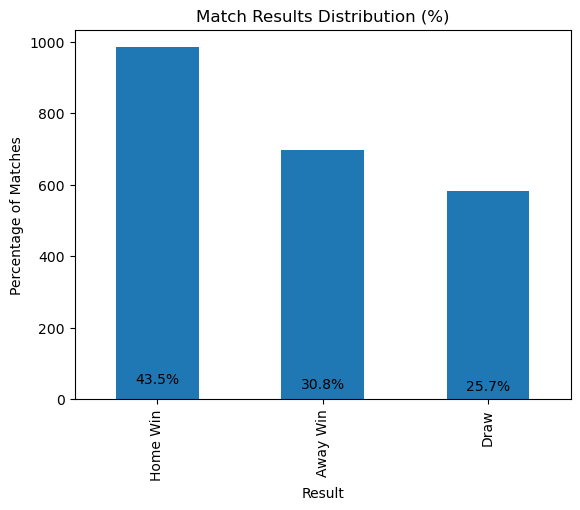

In [63]:
match_df["Result"] = np.select(
    [
        match_df["Home Goals"] > match_df["Away Goals"],
        match_df["Home Goals"] < match_df["Away Goals"]
    ],
    [
        "Home Win",
        "Away Win"
    ],
    default="Draw"
)

match_df["Result"].value_counts().plot(kind="bar")

result_pct = match_df["Result"].value_counts(normalize=True) * 100

ax = result_pct.plot(kind="bar")

plt.title("Match Results Distribution (%)")
plt.xlabel("Result")
plt.ylabel("Percentage of Matches")

for i, v in enumerate(result_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

**Hypotesen om hjemmebanefordel er klart understøttet af vores data - da hjemmebaneholdet tager point i næsten 70% af kampene spillet, og vinder 43%**

### Hypotese: Der er en relation mellem hjemmebanefordel og vundne kampe
2. **Hjemmehold får færre fouls end udehold**

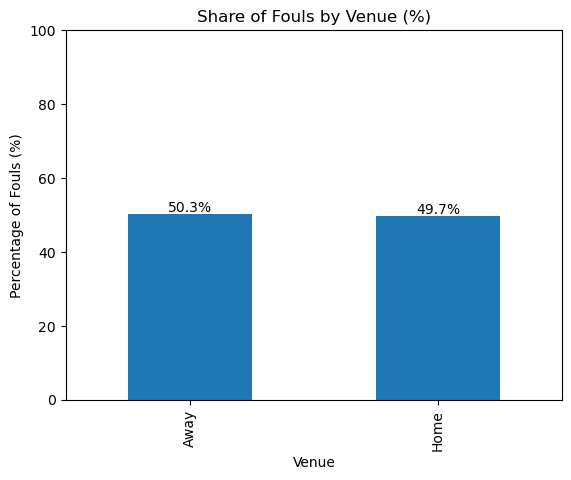

Average fouls home team: 11.194787985865725
Average fouls away team: 11.310512367491166


In [64]:
fouls_pct = cleaneddf.groupby("VENUE")["FOULS"].sum()
fouls_pct = fouls_pct / fouls_pct.sum() * 100

ax = fouls_pct.plot(kind="bar")

plt.title("Share of Fouls by Venue (%)")
plt.xlabel("Venue")
plt.ylabel("Percentage of Fouls (%)")

for i, v in enumerate(fouls_pct):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.ylim(0,100)
plt.show()
home_fouls = team_df[team_df["VENUE"] == "Home"]["FOULS"].mean()
away_fouls = team_df[team_df["VENUE"] == "Away"]["FOULS"].mean()

print("Average fouls home team:", home_fouls)
print("Average fouls away team:", away_fouls)

**Hypotesen om færre fouls dømt mod hjemmebaneholdet kan her afvises**

### Hypotese: Der er en relation mellem hjemmebanefordel og vundne kampe
3. **Udebanehold har flere kort pr foul end hjemmebanehold**

In [65]:
# Samlet kortkolonne i cleaneddf:
cleaneddf["TOTAL_CARDS"] = cleaneddf["YELLOWCARDS"] + cleaneddf["REDCARDS"]

In [66]:
# Cards pr. foul:
cleaneddf["CARDS_PER_FOUL"] = cleaneddf["TOTAL_CARDS"] / cleaneddf["FOULS"]

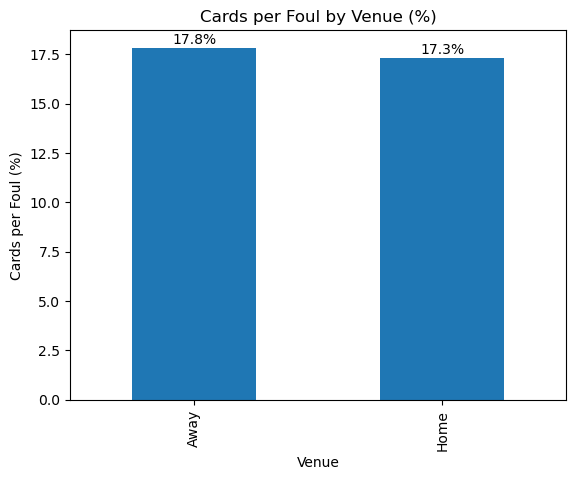

Cards per foul (home teams): 0.17310063523628172
Cards per foul (away teams): 0.1783081771875469


In [67]:
# Sammenligning mellem hjemmebane og udebane:
cleaneddf["TOTAL_CARDS"] = cleaneddf["YELLOWCARDS"] + cleaneddf["REDCARDS"]
cleaneddf["CARDS_PER_FOUL"] = cleaneddf["TOTAL_CARDS"] / cleaneddf["FOULS"].replace(0,1)

cards_pct = cleaneddf.groupby("VENUE")["CARDS_PER_FOUL"].mean() * 100

ax = cards_pct.plot(kind="bar")

plt.title("Cards per Foul by Venue (%)")
plt.xlabel("Venue")
plt.ylabel("Cards per Foul (%)")

for i, v in enumerate(cards_pct):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center")

plt.show()

home_cards_rate = cleaneddf[cleaneddf["VENUE"] == "Home"]["CARDS_PER_FOUL"].mean()
away_cards_rate = cleaneddf[cleaneddf["VENUE"] == "Away"]["CARDS_PER_FOUL"].mean()

print("Cards per foul (home teams):", home_cards_rate)
print("Cards per foul (away teams):", away_cards_rate)

**Hypotesen om flere kort pr. foul til udebanehold kan dermed også afvises**

### Hypotese: Der er en relation mellem spilstrategi og vundne kampe
1. **Højere skud procent fører til flere mål - vist med modeller**

In [68]:
# Vi laver først en ny feature: shot percentage.
team_df = cleaneddf.copy()
team_df["SHOT_PERCENTAGE"] = team_df["SHOTSONTARGET"] / team_df["SHOTS"].replace(0,1)

In [69]:
# Vi finder modstanderens mål i hver kamp
team_df = team_df.sort_values("MATCH_WYID")
team_df["OPP_GOALS"] = team_df.groupby("MATCH_WYID")["GOALS"].transform(lambda x: x.iloc[::-1].values)

## Regression

In [70]:
# Hvis den ikke er installeret
!pip install seaborn
!pip install statsmodels

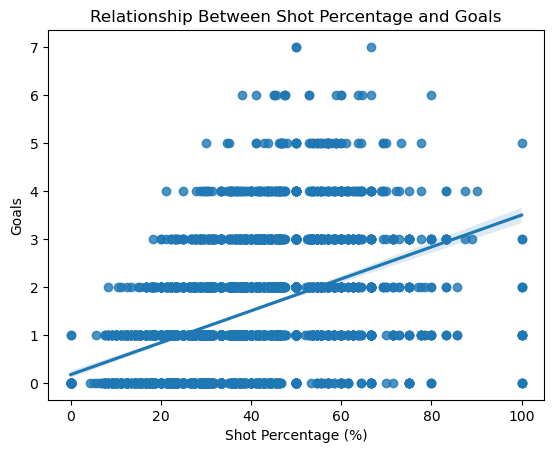

Regression R2 score: 0.3862847577212448
Coefficients: [2.98859073 0.01361742 0.59225715]
                            OLS Regression Results                            
Dep. Variable:                  GOALS   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     937.9
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:54:33   Log-Likelihood:                -6179.1
No. Observations:                4528   AIC:                         1.237e+04
Df Residuals:                    4524   BIC:                         1.239e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [71]:
# Vi bruger lineær regression til at se om skudprocent påvirker antal mål.

features = ["SHOT_PERCENTAGE", "SHOTS", "XG"]
target = "GOALS"

X = team_df[features]
y = team_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

import seaborn as sns

sns.regplot(
    x=team_df["SHOT_PERCENTAGE"] * 100,
    y=team_df["GOALS"]
)

plt.xlabel("Shot Percentage (%)")
plt.ylabel("Goals")

plt.title("Relationship Between Shot Percentage and Goals")

plt.show()

print("Regression R2 score:", r2_score(y_test, pred))
print("Coefficients:", model.coef_)

import statsmodels.api as sm

# samme features som i regressionen
X = team_df[["SHOT_PERCENTAGE", "SHOTS", "XG"]]
y = team_df["GOALS"]

# tilføj konstant (intercept)
X = sm.add_constant(X)

# OLS regression
model_sm = sm.OLS(y, X).fit()

print(model_sm.summary())

**Det kan her ses, at der er en sammenhæng mellem stigende antal mål ud fra mere akkurate skud.**

**På OLS Regression Results kan p-value også aflæses, hvor den på shot percentage, shots og expected goals alle er under 0,05.**
**Dette betyder at der er en overenstemmelse mellem en kamps resultat og disse faktorer**


## Random Forest

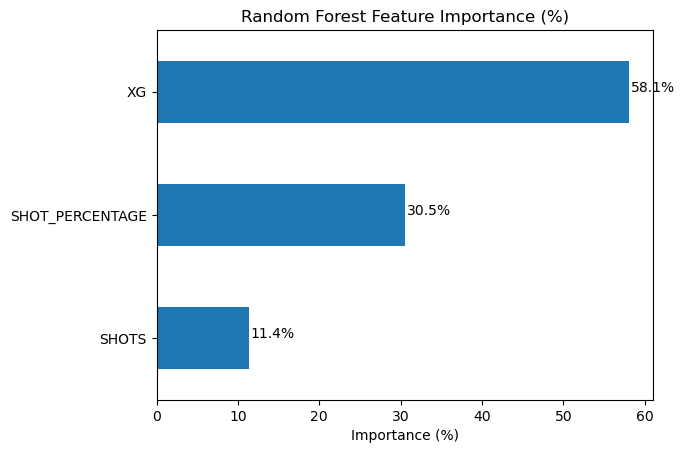

Random Forest R2 score: 0.3279443882961718


In [72]:
# Random Forest kan finde mere komplekse relationer mellem variabler.

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

importance = rf_model.feature_importances_ * 100

feature_importance = pd.Series(importance, index=features)

ax = feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance (%)")
plt.xlabel("Importance (%)")

for i, v in enumerate(feature_importance.sort_values()):
    ax.text(v + 0.2, i, f"{v:.1f}%")

plt.show()

print("Random Forest R2 score:", r2_score(y_test, pred_rf))


**Random Forest-modellen bruges til at identificere, hvilke variabler der bidrager mest til at forudsige antallet af mål. Analysen af feature importance viser, at skudprocent og expected goals (XG) er blandt de vigtigste faktorer for, hvor mange mål et hold scorer.**

## Classification
Her forsøger vi at forudsige om et hold vinder kampen.

In [73]:
team_df["WIN"] = (team_df["GOALS"] > team_df["OPP_GOALS"]).astype(int)

features = [
    "SHOT_PERCENTAGE",
    "SHOTSONTARGET",
    "SHOTS",
    "XG",
    "FOULS",
    "CORNERS",
    "FREEKICKS"
]

X = team_df[features]
y = team_df["WIN"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=2000)

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Match Outcome Prediction")

plt.show()


print("Classification accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

NameError: name 'confusion_matrix' is not defined

**Confusion matrixen viser fordelingen mellem korrekte og forkerte forudsigelser. Modellen klassificerer generelt nederlag bedre end sejre, men viser stadig en rimelig evne til at forudsige kampresultater.**

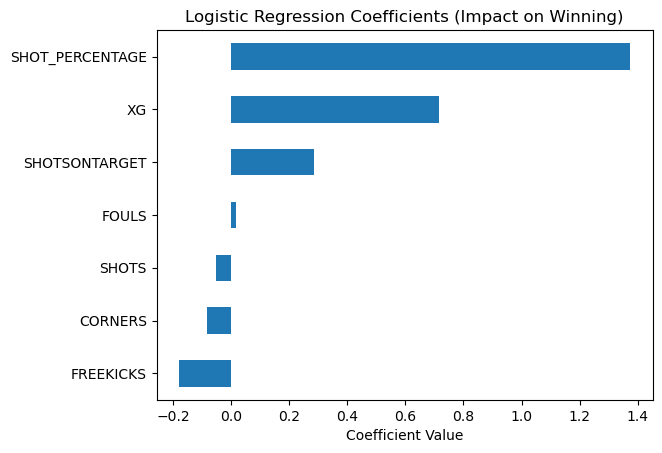

In [74]:
coef = pd.Series(clf.coef_[0], index=features)

coef.sort_values().plot(kind="barh")

plt.title("Logistic Regression Coefficients (Impact on Winning)")
plt.xlabel("Coefficient Value")

plt.show()

**Resultaterne fra Logistic Regression viser, at skudprocent og expected goals (XG) er de vigtigste faktorer for at forudsige, om et hold vinder en kamp. Modellen opnår en accuracy på ca. 73 %, hvilket indikerer en moderat god evne til at klassificere kampresultater baseret på kampstatistikker.**

## Clustering


In [75]:
# Her grupperer vi hold efter deres spillestil.

cluster_features = [
    "SHOTS",
    "SHOTSONTARGET",
    "SHOT_PERCENTAGE",
    "XG",
    "FOULS",
    "CORNERS"
]

X_cluster = team_df[cluster_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)

team_df["Cluster"] = kmeans.fit_predict(X_scaled)

team_df.groupby("Cluster")[cluster_features + ["GOALS"]].mean()

,SHOTS,SHOTSONTARGET,SHOT_PERCENTAGE,XG,FOULS,CORNERS,GOALS
Cluster,,,,,,,
0,16.979457,6.577403,0.394516,2.280694,10.639765,6.892150,2.018342
1,9.907494,2.320258,0.237212,0.985316,11.644028,4.464871,0.729508
2,9.685655,4.814001,0.512748,1.206654,11.367193,3.660947,1.650652


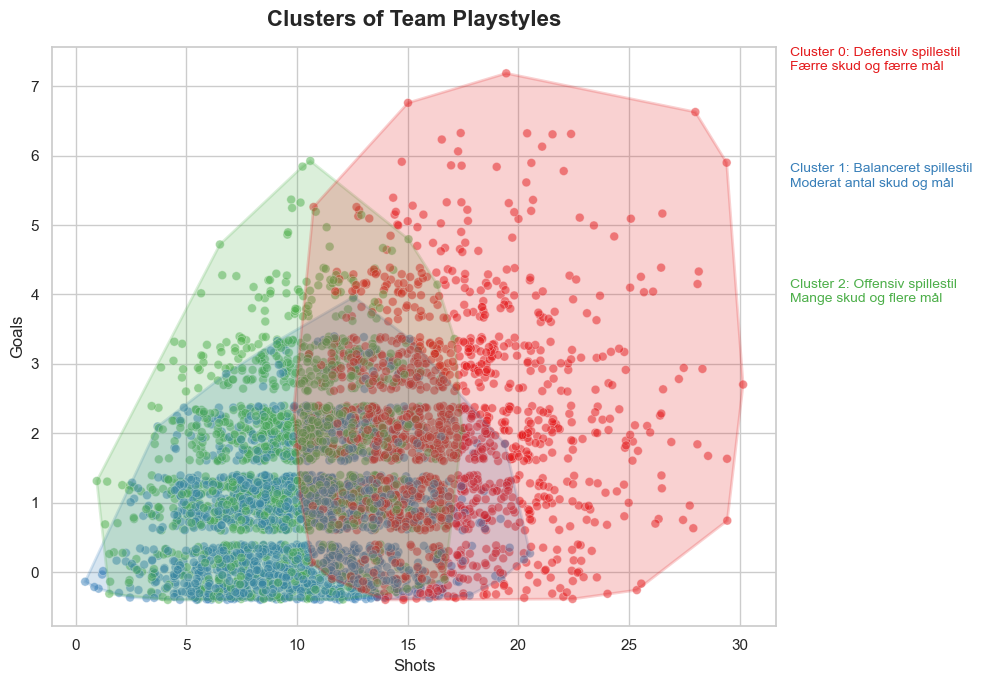

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import numpy as np

# Sætter figurstørrelse og baggrundstema
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Tilføjer jitter for at undgå overlap af punkter
team_df['SHOTS_plot'] = team_df['SHOTS'] + np.random.uniform(-0.6, 0.6, len(team_df))
team_df['GOALS_plot'] = team_df['GOALS'] + np.random.uniform(-0.4, 0.4, len(team_df))

# Definerer faste farver til clusters (matcher forklaringen)
colors = {
    0: '#e41a1c',  # rød
    1: '#377eb8',  # blå
    2: '#4daf4a'   # grøn
}

# Scatterplot med styling
sns.scatterplot(
    data=team_df,
    x='SHOTS_plot',
    y='GOALS_plot',
    hue='Cluster',
    palette=colors,
    alpha=0.5,
    s=40
)

# Tegner convex hull rundt om hver cluster
for cluster_id in team_df['Cluster'].unique():
    points = team_df[team_df['Cluster'] == cluster_id][['SHOTS_plot', 'GOALS_plot']].values
    
    # Kræver mindst 3 punkter
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(
            points[hull.vertices, 0],
            points[hull.vertices, 1],
            alpha=0.2,
            color=colors.get(cluster_id, 'gray'),
            edgecolor=colors.get(cluster_id, 'gray'),
            lw=2
        )

# Titel og akser
plt.title('Clusters of Team Playstyles', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Shots', fontsize=12)
plt.ylabel('Goals', fontsize=12)

# Tilføjer forklarende tekst direkte på grafen
ax = plt.gca()

# Rød tekst
ax.text(1.02, 1,
        "Cluster 0: Defensiv spillestil\nFærre skud og færre mål",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        color='#e41a1c')
# Blå tekst
ax.text(1.02, 0.80,
        "Cluster 1: Balanceret spillestil\nModerat antal skud og mål",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        color='#377eb8')
# Grøn tekst
ax.text(1.02, 0.60,
        "Cluster 2: Offensiv spillestil\nMange skud og flere mål",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        color='#4daf4a')

plt.legend().remove()

plt.tight_layout()
plt.show()

**Rød (Cluster 0)**
**Hold der tager færre skud og scorer færre mål → mere defensiv spillestil.**

**Blå (Cluster 1)**
**Hold med moderat antal skud og mål → balanceret spillestil.**

**Grøn (Cluster 2)**
**Hold med mange skud og flere mål → offensiv spillestil.**

**Overlap opstår fordi der kun visualiseres to variable, og fordi spillestile i praksis ikke er skarpt adskilt.**

**Resultaterne fra analysen viser, at der er en tydelig sammenhæng mellem spillestil og sandsynligheden for at vinde en kamp. Regressionen viser en positiv relation mellem skudprocent, expected goals (XG) og antallet af mål, hvilket indikerer, at hold med mere effektive afslutninger scorer flere mål. Random Forest-modellen understøtter dette ved at vise, at skudprocent og XG er blandt de vigtigste faktorer for at forudsige mål. Logistic Regression-modellen viser desuden, at disse variabler også har en positiv indflydelse på sandsynligheden for at vinde en kamp. Clustering-analysen identificerer forskellige spillestile blandt holdene, hvor mere offensive spillestile generelt er forbundet med flere mål. Samlet set understøtter analyserne hypotesen om, at spillestil har en betydning for, om et hold vinder en kamp.**

### Mængden af kort et hold modtager har en korrelation til kampens resultat

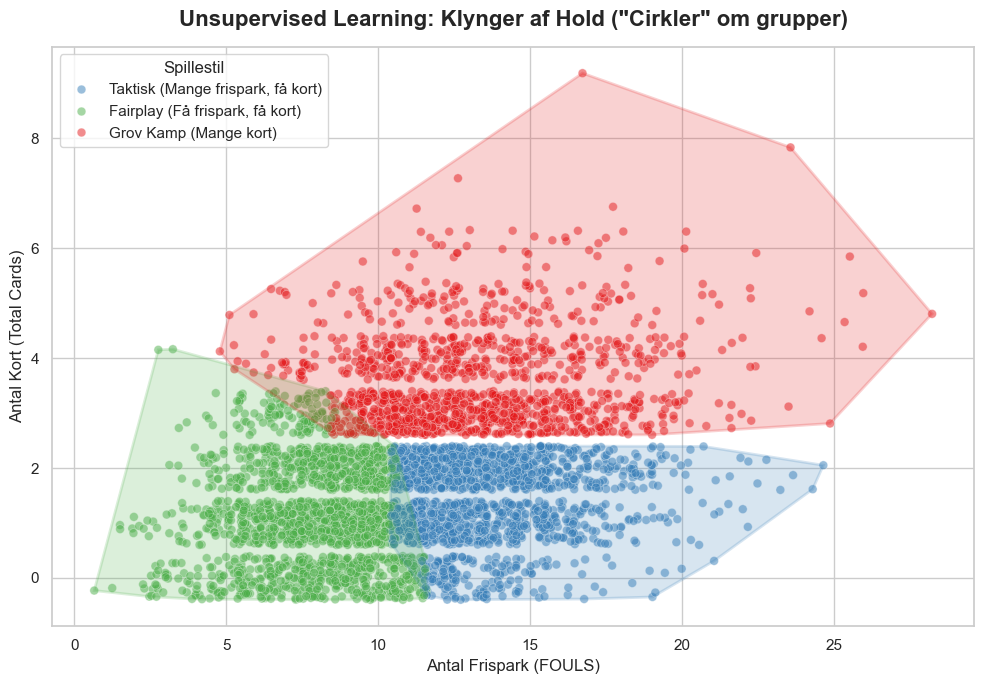

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull


# TRIN 1: Klargøring af data
# ==========================================

cardsdf = pd.read_csv('cleaneddf.csv')

# Vi sørger for at 'Total Cards' findes i vores datasæt (Kombination af gule og røde kort)
if 'Total Cards' not in cardsdf.columns:
    cardsdf['Total Cards'] = cardsdf['YELLOWCARDS'] + cardsdf['REDCARDS']

# Vi trækker de to kolonner ud, som vi vil bruge til machine learning (Total Cards og Fouls)
cardsdf_cluster = cardsdf[['Total Cards', 'FOULS']].copy()

# Fjern eventuelle rækker der mangler data
cardsdf_cluster = cardsdf_cluster.dropna()

# ==========================================
# TRIN 2: Træning af vores maskine (Unsupervised ML)
# ==========================================

scaler = StandardScaler()
data_scaled = scaler.fit_transform(cardsdf_cluster)

# Vi beder maskinen om at finde 3 klynger
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Maskinen gætter/predicter nu på, hvilken gruppe hver kamp tilhører (0, 1 eller 2)
cardsdf_cluster['Gruppe_Nummer'] = kmeans.fit_predict(data_scaled)

# ==========================================
# TRIN 3: Navngivning af vores nye grupperingerx
# ==========================================

cards_avg = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Total Cards', 'FOULS']
)

cards_avg['Gruppe_Nummer'] = [0, 1, 2]

# Sortér grupperne efter antal kort
cards_avg = cards_avg.sort_values(by=['Total Cards'])

navne = {
    cards_avg.iloc[0]['Gruppe_Nummer']: 'Fairplay (Få frispark, få kort)',
    cards_avg.iloc[1]['Gruppe_Nummer']: 'Taktisk (Mange frispark, få kort)',
    cards_avg.iloc[2]['Gruppe_Nummer']: 'Grov Kamp (Mange kort)'
}

cardsdf_cluster['Spillestil'] = cardsdf_cluster['Gruppe_Nummer'].map(navne)

# ==========================================
# TRIN 4: Plotting
# ==========================================

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Spreder prikkerne lidt (Jitter)
cardsdf_cluster['FOULS_plot'] = cardsdf_cluster['FOULS'] + np.random.uniform(-0.6, 0.6, len(cardsdf_cluster))
cardsdf_cluster['Cards_plot'] = cardsdf_cluster['Total Cards'] + np.random.uniform(-0.4, 0.4, len(cardsdf_cluster))

farver = {
    'Fairplay (Få frispark, få kort)': '#4daf4a',
    'Taktisk (Mange frispark, få kort)': '#377eb8',
    'Grov Kamp (Mange kort)': '#e41a1c'
}

# Tegner prikkerne
sns.scatterplot(
    data=cardsdf_cluster,
    x='FOULS_plot',
    y='Cards_plot',
    hue='Spillestil',
    palette=farver,
    alpha=0.5,
    s=40
)

# Tegner cirkler rundt om grupperne
for gruppe_navn in cardsdf_cluster['Spillestil'].unique():
    prikker = cardsdf_cluster[cardsdf_cluster['Spillestil'] == gruppe_navn][['FOULS_plot', 'Cards_plot']].values
    
    if len(prikker) >= 3:
        hull = ConvexHull(prikker)
        plt.fill(
            prikker[hull.vertices, 0],
            prikker[hull.vertices, 1],
            alpha=0.2,
            color=farver[gruppe_navn],
            edgecolor=farver[gruppe_navn],
            lw=2
        )

plt.title('Unsupervised Learning: Klynger af Hold ("Cirkler" om grupper)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Antal Frispark (FOULS)', fontsize=12)
plt.ylabel('Antal Kort (Total Cards)', fontsize=12)
plt.legend(title='Spillestil', loc='upper left')

plt.tight_layout()
plt.show()

/var/folders/qm/ybqngckn3l18t10bwlsg57hm0000gn/T/ipykernel_67096/1598608188.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_udfald = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(find_udfald).dropna(subset=['Resultat'])


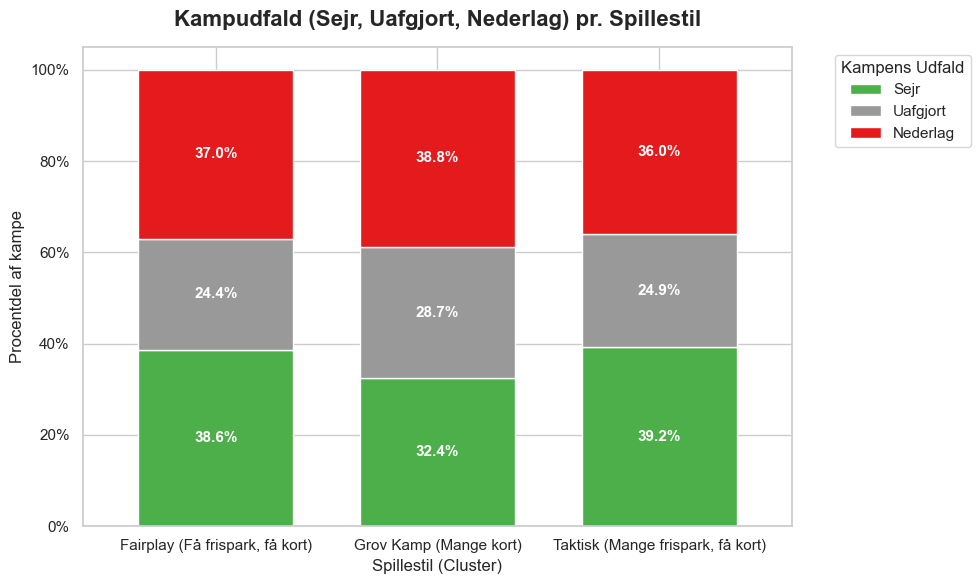

In [78]:
import matplotlib.ticker as mtick

# ==========================================
# TRIN 5: Besvarelse af hypotese (Med stacked bar chart)
# ==========================================

# Skaber en kolonne der indeholder alle 3 resultater (ikke kun 1 eller 0)
def find_udfald(kamp):
    if len(kamp) == 2:
        maal = kamp['GOALS'].values
        if maal[0] > maal[1]:
            kamp['Resultat'] = ['Sejr', 'Nederlag']
        elif maal[0] < maal[1]:
            kamp['Resultat'] = ['Nederlag', 'Sejr']
        else:
            kamp['Resultat'] = ['Uafgjort', 'Uafgjort']
    else:
        kamp['Resultat'] = np.nan
    return kamp

# Kører funktionen på vores kamp-data
df_udfald = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(find_udfald).dropna(subset=['Resultat'])
cardsdf_cluster['Resultat'] = df_udfald['Resultat']

# Regner procentfordelingen ud (hvor stor en %-del er Sejr, Uafgjort, Nederlag pr. cluster)
fordeling = cardsdf_cluster.groupby(['Spillestil', 'Resultat']).size().unstack(fill_value=0)
fordeling_pct = fordeling.div(fordeling.sum(axis=1), axis=0)  # Konverter antal til procenter

# Sorterer rækkefølgen så de ligger logisk (Sejr nederst, Uafgjort i midten, Nederlag øverst)
fordeling_pct = fordeling_pct[['Sejr', 'Uafgjort', 'Nederlag']]

# Plotter som Stacked Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Sætter farver for resultater (Grøn = Sejr, Grå = Uafgjort, Rød = Nederlag)
farver_resultat = ['#4daf4a', '#999999', '#e41a1c']

# Tegner plottet
fordeling_pct.plot(kind='bar', stacked=True, color=farver_resultat, ax=ax, edgecolor='white', width=0.7)

plt.title('Kampudfald (Sejr, Uafgjort, Nederlag) pr. Spillestil', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Spillestil (Cluster)', fontsize=12)
plt.ylabel('Procentdel af kampe', fontsize=12)
plt.xticks(rotation=0)  # Sørg for at teksten under søjlerne står vandret

# Gør y-aksen til pæne procenter (0% - 100%)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Skriv procenttallet direkte indeni hver farvet kasse
for c in ax.containers:
    labels = [f'{v.get_height()*100:.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold', fontsize=11)

# Flyt forklaringen (Legend) uden for selve diagrammet
plt.legend(title='Kampens Udfald', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

--- BEVIS FRA SUPERVISED LEARNING ---
Modellens korrelation for Kort-forskel: -0.1202
(Et negativt tal beviser, at hvis du får FLERE kort end modstanderen, falder chancen for at vinde)



/var/folders/qm/ybqngckn3l18t10bwlsg57hm0000gn/T/ipykernel_67096/2752946837.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cardsdf = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(klargor_regression).dropna(subset=['Vandt', 'Card_Diff'])


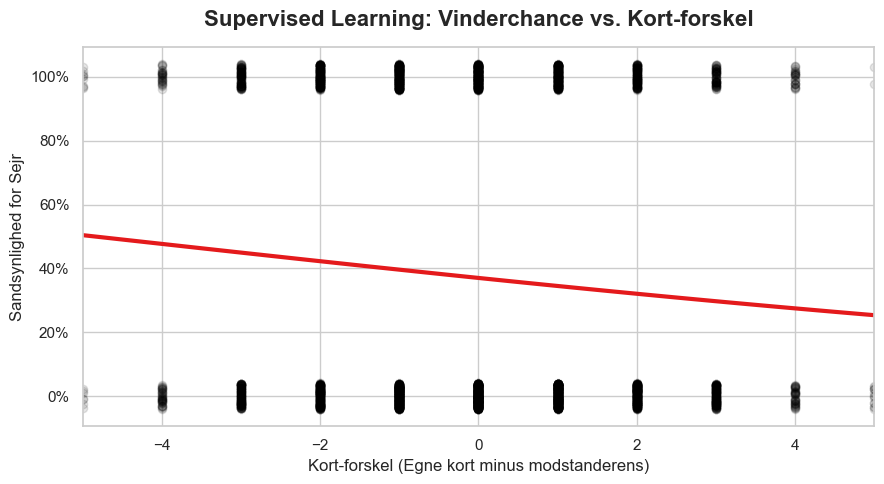

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# TRIN 6: SUPERVISED LEARNING & PLOT (Regression)
# ==========================================

# Indlæs en frisk kopi af dataen
cardsdf = pd.read_csv('cleaneddf.csv')

# Vi sikrer, at 'Total Cards' er klar
if 'Total Cards' not in cardsdf.columns:
    cardsdf['Total Cards'] = cardsdf['YELLOWCARDS'] + cardsdf['REDCARDS']

# 1. Klargør Target (Vinder) og Feature (Kort-forskel)
def klargor_regression(kamp):
    if len(kamp) == 2:
        # Find vinder (1 for sejr, 0 for tab/uafgjort)
        maal = kamp['GOALS'].values
        if maal[0] > maal[1]:
            kamp['Vandt'] = [1, 0]
        elif maal[0] < maal[1]:
            kamp['Vandt'] = [0, 1]
        else:
            kamp['Vandt'] = [0, 0]
            
        # Find kort-forskel (Vores kort minus modstanderens kort)
        kort = kamp['Total Cards'].values
        kamp['Card_Diff'] = [kort[0] - kort[1], kort[1] - kort[0]]
    else:
        kamp['Vandt'] = np.nan
        kamp['Card_Diff'] = np.nan
    return kamp

# Anvend funktionen og fjern manglende data
cardsdf = cardsdf.groupby('MATCH_WYID', group_keys=False).apply(klargor_regression).dropna(subset=['Vandt', 'Card_Diff'])

# Sørg for at datatyperne er tal (ellers giver seaborn plottet en flad linje)
cardsdf['Card_Diff'] = cardsdf['Card_Diff'].astype(float)
cardsdf['Vandt'] = cardsdf['Vandt'].astype(int)


# 2. Vi opdeler i features (Kort-forskel) og target (Vandt de?)
X = cardsdf[['Card_Diff']]
y = cardsdf['Vandt']

# 3. Splitter data i træning (80%) og test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Træner den logistiske regressionsmodel
model = LogisticRegression()
model.fit(X_train, y_train)

# Udskriv matematisk bevis i konsollen
print("--- BEVIS FRA SUPERVISED LEARNING ---")
print(f"Modellens korrelation for Kort-forskel: {model.coef_[0][0]:.4f}")
print("(Et negativt tal beviser, at hvis du får FLERE kort end modstanderen, falder chancen for at vinde)\n")

# 5. Plot af Regressionen (Sandsynlighed for sejr vs. Kort-forskel)
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

sns.regplot(
    data=cardsdf, 
    x='Card_Diff', 
    y='Vandt', 
    logistic=True, 
    ci=None,
    y_jitter=0.04, # 
    scatter_kws={'alpha': 0.1, 'color': 'black'}, 
    line_kws={'color': '#e41a1c', 'linewidth': 3}
)

plt.title('Supervised Learning: Vinderchance vs. Kort-forskel', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Kort-forskel (Egne kort minus modstanderens)', fontsize=12)
plt.ylabel('Sandsynlighed for Sejr', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Sætter x-aksen til at vise de mest almindelige forskelle for et pænere plot
plt.xlim(-5, 5) 

plt.tight_layout()
plt.show()

### Conclusion
#### Hypotese
Mængden af kort et hold modtager har en korrelation til kampens resultat (hvem der vinder)

Forskellen på at spille fair eller taktisk er så lille at den er ubetydelig. Til gengæld falder vinderchancen markant når spillet bliver groft. Konklusionen er derfor at hold vinder oftest ved at spille taktisk med mange frispark og få kort frem for at trække strafkort. Dette viser vores regressionsplot også. Vinder chancen falder jo flere kort man får i forhold til modstanderen.

### Mængden af hjørnespark har en korrelation til at vinde kampe

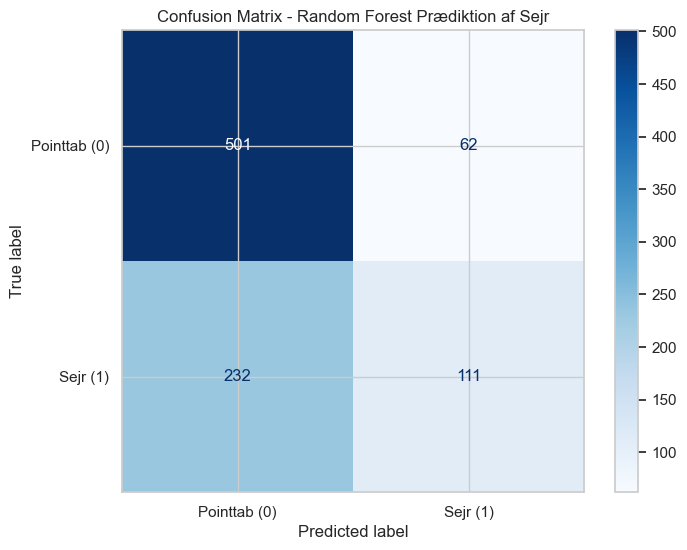

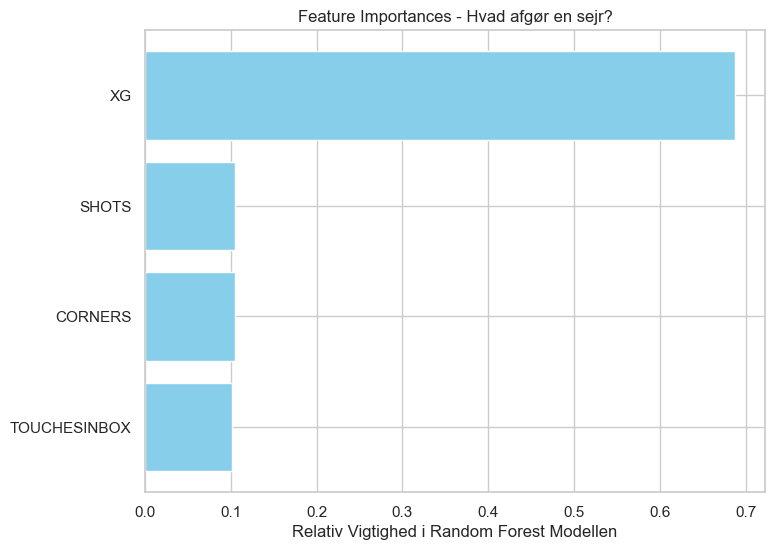

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For at sikre, at vi altid starter med de oprindelige data
# Vi fjerner midlertidigt WIN og OPPONENT kolonnerne, hvis de allerede eksisterer i cleaneddf
cols_to_drop = ['OPPONENT_TEAM_WYID', 'OPPONENT_GOALS', 'WIN']
df_safe = cleaneddf.drop(columns=[col for col in cols_to_drop if col in cleaneddf.columns])

# Her genskaber vi target variablen WIN ud fra det rene datasæt
opp_df = df_safe[['MATCH_WYID', 'TEAM_WYID', 'GOALS']].copy()
opp_df.columns = ['MATCH_WYID', 'OPPONENT_TEAM_WYID', 'OPPONENT_GOALS']
df_merged = pd.merge(df_safe, opp_df, on='MATCH_WYID')

# Fjerner rækker hvor holdet matches mod sig selv
df_merged = df_merged[df_merged['TEAM_WYID'] != df_merged['OPPONENT_TEAM_WYID']]

# Skaber WIN-kolonnen
df_merged['WIN'] = (df_merged['GOALS'] > df_merged['OPPONENT_GOALS']).astype(int)

# Opsætter model og split data
features = ['CORNERS', 'XG', 'TOUCHESINBOX', 'SHOTS']
X = df_merged[features]
y = df_merged['WIN']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Træning af Random Forest (Supervised)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# PLOT 1: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pointtab (0)', 'Sejr (1)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Random Forest Prædiktion af Sejr')
plt.show()

# PLOT 2: FEATURE IMPORTANCE
importances = rf_model.feature_importances_
indices = np.argsort(importances)
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Feature Importances - Hvad afgør en sejr?')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relativ Vigtighed i Random Forest Modellen')
plt.show()

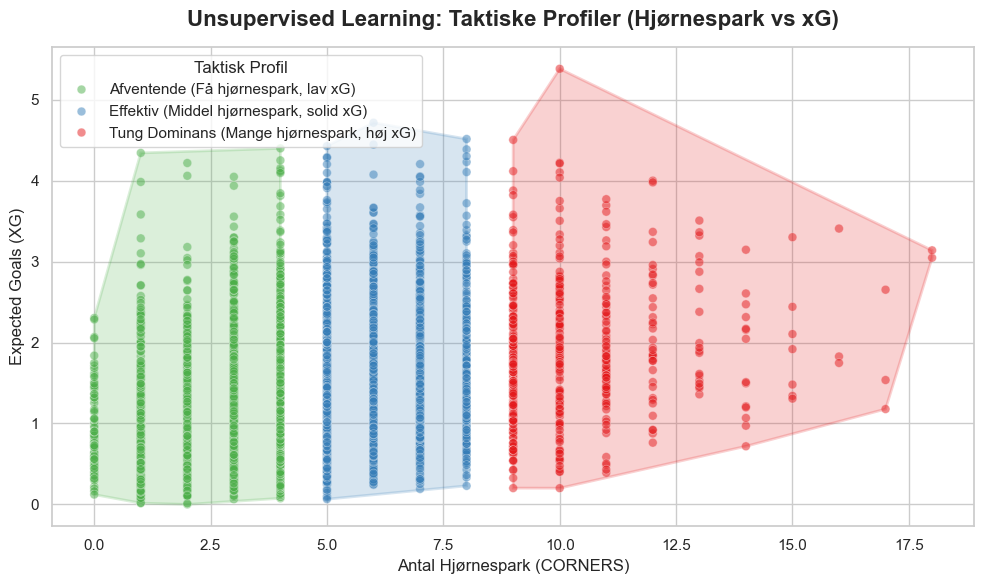

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import warnings
warnings.filterwarnings('ignore')

# Sikker indlæsning og klargøring af WIN
cols_to_drop = ['OPPONENT_TEAM_WYID', 'OPPONENT_GOALS', 'WIN']
df_safe = cleaneddf.drop(columns=[col for col in cols_to_drop if col in cleaneddf.columns])

opp_df = df_safe[['MATCH_WYID', 'TEAM_WYID', 'GOALS']].copy()
opp_df.columns = ['MATCH_WYID', 'OPPONENT_TEAM_WYID', 'OPPONENT_GOALS']
df_merged = pd.merge(df_safe, opp_df, on='MATCH_WYID')
df_merged = df_merged[df_merged['TEAM_WYID'] != df_merged['OPPONENT_TEAM_WYID']]
df_merged['WIN'] = (df_merged['GOALS'] > df_merged['OPPONENT_GOALS']).astype(int)

# Udvælger data og kører K-Means
cluster_features = ['CORNERS', 'XG']
df_merged = df_merged.dropna(subset=cluster_features)
X_cluster = df_merged[cluster_features]

kmeans = KMeans(n_clusters=3, random_state=42)
df_merged['Cluster'] = kmeans.fit_predict(X_cluster)

# Dynamisk navngivning af klynger for at undgå at farver bytter plads
# Vi finder gennemsnittet af hjørnespark for hver cluster og sorterer dem
centroids = df_merged.groupby('Cluster')['CORNERS'].mean().sort_values()

# Den med færrest corners er index 0, midterste er index 1, flest er index 2
cluster_mapping = {
    centroids.index[0]: 'Afventende (Få hjørnespark, lav xG)',
    centroids.index[1]: 'Effektiv (Middel hjørnespark, solid xG)',
    centroids.index[2]: 'Tung Dominans (Mange hjørnespark, høj xG)'
}
df_merged['Taktisk Profil'] = df_merged['Cluster'].map(cluster_mapping)

# Her vælger vi vores eget design med farvevalg
farver = {
    'Afventende (Få hjørnespark, lav xG)': '#4daf4a', # Grøn
    'Effektiv (Middel hjørnespark, solid xG)': '#377eb8', # Blå
    'Tung Dominans (Mange hjørnespark, høj xG)': '#e41a1c' # Rød
}

plt.figure(figsize=(10, 6))

# Tegner prikkerne
sns.scatterplot(
    data=df_merged,
    x='CORNERS',
    y='XG',
    hue='Taktisk Profil',
    palette=farver,
    alpha=0.5,
    s=40
)

# Tegner polygon-cirkler (ConvexHull) rundt om grupperne
for gruppe_navn in df_merged['Taktisk Profil'].unique():
    # Udtrækker x og y koordinater for den specifikke gruppe
    prikker = df_merged[df_merged['Taktisk Profil'] == gruppe_navn][['CORNERS', 'XG']].values
    
    # Der kræves mindst 3 punkter for at tegne en 2D polygon
    if len(prikker) >= 3:
        hull = ConvexHull(prikker)
        plt.fill(
            prikker[hull.vertices, 0],
            prikker[hull.vertices, 1],
            alpha=0.2,
            color=farver[gruppe_navn],
            edgecolor=farver[gruppe_navn],
            lw=2
        )

plt.title('Unsupervised Learning: Taktiske Profiler (Hjørnespark vs xG)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Antal Hjørnespark (CORNERS)', fontsize=12)
plt.ylabel('Expected Goals (XG)', fontsize=12)
plt.legend(title='Taktisk Profil', loc='upper left')

plt.tight_layout()
plt.show()

### Conclusion

#### Hypotese
Mængden af hjørnespark har en korrelation til at vinde kampe


Hypotesen afvises. Mængden af hjørnespark har ikke en stærk, isoleret korrelation til at vinde fodboldkampe.
Vores Machine Learning-modeller beviser dette på to fronter:

Supervised Learning (Random Forest): Modellen viser, at hjørnespark har en meget lav "Feature Importance". For at gætte kampens vinder kigger algoritmen næsten udelukkende på chancekvalitet (xG) og antal skud, mens den stort set ignorerer antallet af hjørnespark.

Unsupervised Learning (K-Means Clustering): Vores klyngeanalyse samlede holdene i taktiske profiler. Her så vi direkte, at gruppen med absolut flest hjørnespark ("Tung Dominans") ironisk nok var den klynge med den laveste vinderprocent.

Sammenfatning:
Hjørnespark fører ikke automatisk til sejr. Rigtig mange hjørnespark indikerer ofte blot, at et hold stanger mod et kompakt forsvar uden at kunne omsætte overtaget til farlige chancer. Kvalitet (xG) slår kvantitet (hjørnespark).